# Demo 2D RL Environment for the PURT Course using Dynamic Programming

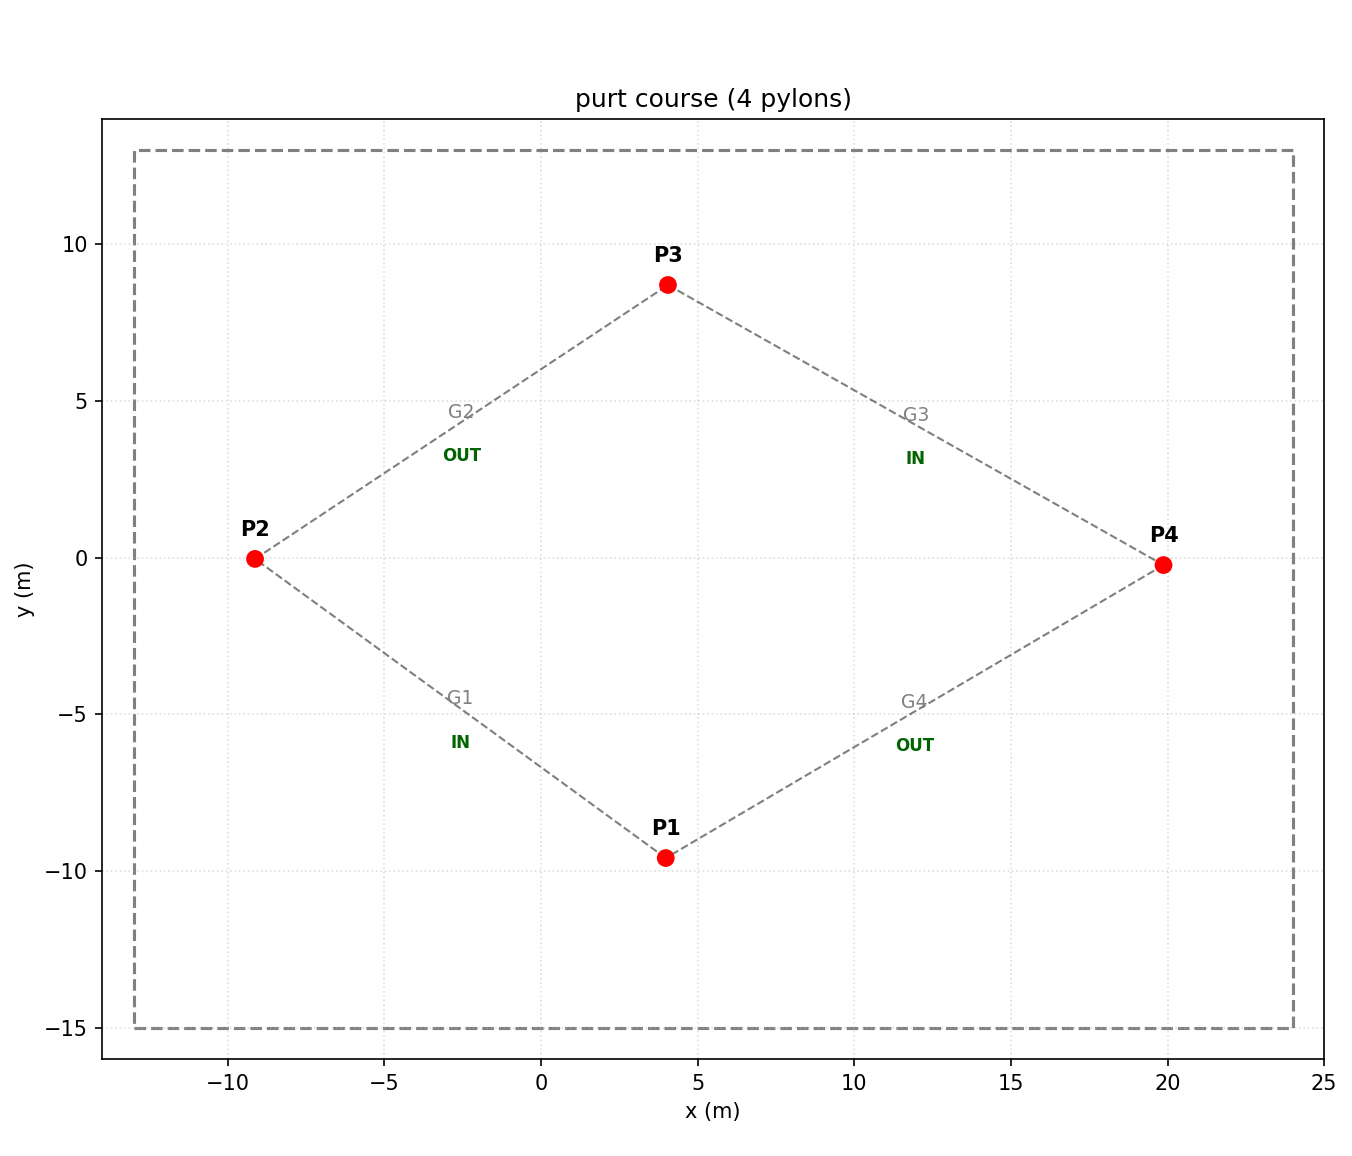

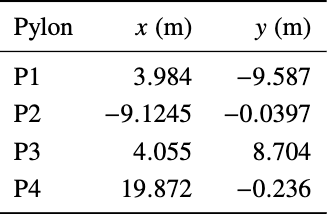

## Environment

### State Space
$\mathcal{S} \in \mathbb{Z} \cap \left[0,N_{\text{grid}}^2-1\right] \times \mathbb{Z} \cap \left[0,N_{\text{midpoint}}\right]$

$N_{\text{grid}}$: Number of grid cells in a single direction (we assume the grid is square)

$N_{\text{midpoint}}$: Number of midpoints between pylons

$\mathbb{Z} \cap \left[0,N_{\text{grid}}^2-1\right]$: 2D square grid of size $N_{\text{grid}} \times N_{\text{grid}}$ compressed into a scalar integer of maximum value $N_{\text{grid}}^2 - 1$ corresponding to the grid index number

$\mathbb{Z} \cap \left[0,N_{\text{midpoint}}\right]$: Number of midpoints visited

### Observation Space
$\mathcal{O} = \mathcal{S}$ (Same as the state space)

### Action Space
$\mathcal{A} \in \{0,1,2,3\}$

0: Up

1: Down

2: Left

3: Right

### Tranisition Logic
* Move deterministicaly in the direction of action as long as there is room to move and the current cell does not intersect a pylon.
* If there is no room to move in the direction of action or if the current cell intersects a pylon, remain stationary and end the episode.

### Rewards
* Reached next midpoint in order: $+1$
* Returned to starting point (endpoint) after going through all midpoints: $+1$
* Moved to a cell intersecting a pylon: $-1$

In [70]:
# Environment imports
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

In [71]:
# Simple PURT Environment
class SimplePURT(gym.Env):
    # PYLON_COORDINATES: Bottom left corner is (0,0), Top right corner is (1,1)
    def __init__(self, GRID_N=10, MAX_STEPS=100, REWARDS={"neutral": 0, "midpoint": 1, "endpoint": 1, "pylon": -1}, INIT_STATE=np.asarray([0, 0]), PYLON_COORDINATES=np.array([[0.2, 0.2],[0.2,0.8],[0.8,0.8],[0.8,0.2]])):
        super(SimplePURT, self).__init__()
        
        self.GRID_N = GRID_N
        self.MAX_STEPS = MAX_STEPS
        self.REWARDS = REWARDS
        self.INIT_STATE = INIT_STATE.copy()

        self.PYLON_GRID_COORDINATES = np.round(PYLON_COORDINATES * (GRID_N - 1)).astype(int) # Convert pylon coordinates to grid coordinates
        self.PYLON_GRID_INDICES = self.PYLON_GRID_COORDINATES[:, 0] + self.PYLON_GRID_COORDINATES[:, 1] * GRID_N # Convert grid coordinates to grid indices
        
        self.PYLON_MIDPOINT_COORDINATES = np.zeros_like(PYLON_COORDINATES)
        for i in range(PYLON_COORDINATES.shape[0]):
            self.PYLON_MIDPOINT_COORDINATES[i] = 0.5 * (PYLON_COORDINATES[i] + PYLON_COORDINATES[(i + 1) % PYLON_COORDINATES.shape[0]]) # Midpoint between pylon i and pylon (i+1)
        self.PYLON_MIDPOINT_GRID_COORDINATES = np.round(self.PYLON_MIDPOINT_COORDINATES * (GRID_N - 1)).astype(int) # Convert midpoint coordinates to grid coordinates
        self.PYLON_MIDPOINT_INDICES = self.PYLON_MIDPOINT_GRID_COORDINATES[:, 0] + self.PYLON_MIDPOINT_GRID_COORDINATES[:, 1] * GRID_N # Convert grid coordinates to grid indices

        self.observation_space = spaces.MultiDiscrete([
            GRID_N * GRID_N, # Grid index number
            len(self.PYLON_MIDPOINT_INDICES) + 1 # Number of midpoints visited
        ])
        self.action_space = spaces.Discrete(4) # Up, Down, Left, Right
        self.state = INIT_STATE.copy() # Initial state
        self.n_steps = 0 # Keep track of the number of steps taken
        self.state_history = [INIT_STATE.copy()] # Keep track of the state history
        self.action_history = [] # Keep track of the action history
        
    def reset(self):
        self.state = self.INIT_STATE.copy()
        self.n_steps = 0
        self.state_history = [self.state.copy()]
        self.action_history = []
        return self.get_observation(), self.get_info()

    def step(self, action, ignore_truncation=False):
        new_state = self.state.copy()
        reward = self.REWARDS["neutral"]
        done = False
        truncated = False

        # 2D movement
        if action == 0:
            new_state[0] = (self.state[0] + self.GRID_N) if self.state[0] < self.GRID_N * (self.GRID_N - 1) else self.state[0]
        elif action == 1:
            new_state[0] = (self.state[0] - self.GRID_N) if self.state[0] >= self.GRID_N else self.state[0]
        elif action == 2:
            new_state[0] = (self.state[0] - 1) if self.state[0] % self.GRID_N != 0 else self.state[0]
        elif action == 3:
            new_state[0] = (self.state[0] + 1) if (self.state[0] + 1) % self.GRID_N != 0 else self.state[0]

        # Reward
        if new_state[0] != self.state[0]:
            if new_state[0] in self.PYLON_GRID_INDICES:
                reward += self.REWARDS["pylon"] # Penalty for hitting a pylon
                done = True
            elif new_state[1] < len(self.PYLON_MIDPOINT_INDICES):
                if new_state[0] == self.PYLON_MIDPOINT_INDICES[new_state[1]]:
                    reward += self.REWARDS["midpoint"] # Reward for visiting midpoints in order
                    new_state[1] += 1 # Move to the next midpoint
            elif new_state[0] == self.INIT_STATE[0]:
                reward += self.REWARDS["endpoint"] # Reward for returning to initial state
                done = True
        else:
            done = True # If the agent tries to move out of bounds, end the episode

        self.state = new_state
        self.state_history.append(new_state.copy())
        self.action_history.append(action)

        if not ignore_truncation:
            self.n_steps += 1
            truncated = self.n_steps >= self.MAX_STEPS # Truncate the episode after MAX_STEPS

        return self.get_observation(), reward, done, truncated, self.get_info()
    
    def get_observation(self):
        return self.state
    
    def get_info(self):
        return {"state_history": self.state_history, "action_history": self.action_history}
    
    def render(self, ax=None, title=None, legend_outside=True):
        # 1. Initialize the plot (or draw into a caller-provided axes for side-by-side comparisons)
        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(7, 7))
        ax.set_xlim(-0.5, self.GRID_N - 0.5)
        ax.set_ylim(-0.5, self.GRID_N - 0.5)
        
        # Configure grid lines to match your matrix index boundary points
        ax.set_xticks(np.arange(self.GRID_N))
        ax.set_yticks(np.arange(self.GRID_N))
        ax.grid(True, which='both', color='gainsboro', linestyle='-', linewidth=0.5)
        
        # 2. Extract and Plot Pylons (|)
        px = self.PYLON_GRID_COORDINATES[:, 0]
        py = self.PYLON_GRID_COORDINATES[:, 1]
        ax.scatter(px, py, color='firebrick', marker='|', s=250, linewidths=3, label='Pylon')
            
        # 3. Extract and Plot Midpoints (o)
        mx = self.PYLON_MIDPOINT_GRID_COORDINATES[:, 0]
        my = self.PYLON_MIDPOINT_GRID_COORDINATES[:, 1]
        ax.scatter(mx, my, color='darkorange', marker='o', s=100, facecolors='none', edgecolors='darkorange', linewidths=2, label='Midpoint')

        # 4. Process and Plot Agent Path Line (With Smooth Continuous Gradient)
        if self.state_history:
            path_x = np.array([state[0] % self.GRID_N for state in self.state_history])
            path_y = np.array([state[0] // self.GRID_N for state in self.state_history])
            
            # --- Continuous Gradient Line Implementation via Interpolation ---
            if len(path_x) > 1:
                # Interpolate 100 fine points between every step to blend colors flawlessly
                num_interp_points = (len(path_x) - 1) * 100
                t_original = np.arange(len(path_x))
                t_fine = np.linspace(0, len(path_x) - 1, num_interp_points)
                
                fine_x = np.interp(t_fine, t_original, path_x)
                fine_y = np.interp(t_fine, t_original, path_y)
                
                # Reshape the upscaled points into micro-segments
                points = np.array([fine_x, fine_y]).T.reshape(-1, 1, 2)
                segments = np.concatenate([points[:-1], points[1:]], axis=1)
                
                # --- CONTROLLING THE COLOR SHIFT RATE ---
                # Default was np.linspace(0, 1, len(segments))
                # Adjust 'max_shift' to control how far along the colormap the path gets.
                # 0.4 means it will only shift through 40% of the colormap over the entire path.
                max_shift = 0.5 
                path_progression = np.linspace(0, max_shift, len(segments))
                # ----------------------------------------
                
                lc = LineCollection(segments, cmap='plasma', linewidths=3, alpha=0.9, zorder=2)
                lc.set_array(path_progression)
                
                # CRITICAL: Fix the colormap scaling limits so 1.0 remains the absolute ceiling
                lc.set_clim(0, 1) 
                
                ax.add_collection(lc)
                
                # Add a dummy handle so 'Agent Path' still shows up nicely in the legend
                from matplotlib.lines import Line2D
                legend_dummy = Line2D([0], [0], color=plt.get_cmap('plasma')(0.5), lw=3, label='Agent Path')
                # We will handle adding this dummy to the legend safely below
            # -----------------------------------------------------------------
            
            # Overlay directional action markers at each step along the line
            action_markers = {0: '^', 1: 'v', 2: '<', 3: '>'}
            for i, action in enumerate(self.action_history):
                if action in action_markers:
                    ax.scatter(path_x[i], path_y[i], color='dodgerblue', marker=action_markers[action], s=80, zorder=3)
            
            # Distinctly mark Start and Finish states
            ax.scatter(path_x[0], path_y[0], color='forestgreen', marker='s', s=120, label='Start', zorder=4)
            ax.scatter(path_x[-1], path_y[-1], color='gold', marker='*', s=250, edgecolor='black', label='Finish', zorder=4)

        # 5. Labels and Legends
        ax.set_title(title or "SimplePURT Grid Visualization", fontsize=14, fontweight='bold', pad=15)
        ax.set_aspect('equal')
        
        # Adjust legend rendering to cleanly include our gradient dummy line
        handles, labels = ax.get_legend_handles_labels()
        if self.state_history and len(path_x) > 1:
            handles.append(legend_dummy)
            labels.append('Agent Path')
        if legend_outside:
            ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
        else:
            # Compact in-axes legend so multiple subplots can sit side by side without overlapping
            ax.legend(handles, labels, loc='upper right', fontsize=8, framealpha=0.9)
        
        if standalone:
            plt.tight_layout()
            plt.show()

## Policy Iteration

In [72]:
# Policy evaluation function
def policy_evaluation(env, policy, V, discount_factor, theta):
    while True:
        delta = 0
        for s in np.ndindex(*env.observation_space.nvec):
            s = np.asarray(s)
            old_v, V[*s] = V[*s], 0
            env.state = s # Set the environment state to the current state
            next_state, reward, _, _, _ = env.step(policy[*s], ignore_truncation=True)
            V[*s] = reward + discount_factor * V[*next_state] # Bellman Expectation equation
            delta = max(delta, np.abs(old_v - V[*s]))
        if delta < theta: # Convergence condition
            break
    return V

In [73]:
# Policy improvement function
def policy_improvement(env, policy, V, discount_factor):
    policy_stable = True
    for s in np.ndindex(*env.observation_space.nvec):
        s = np.asarray(s)
        old_action = policy[*s]
        Q = np.zeros(env.action_space.n, dtype=np.float64)
        for a in range(env.action_space.n):
            env.state = s # Set the environment state to the current state
            next_state, reward, _, _, _ = env.step(a, ignore_truncation=True)
            Q[a] = reward + discount_factor * V[*next_state] # Q-values based on the current state-values
        policy[*s] = np.argmax(Q) # Greedy policy
        if old_action != policy[*s]: # Stability condition
            policy_stable = False
    return policy, policy_stable

In [74]:
# Policy iteration function
def policy_iteration(env, discount_factor, theta):
    policy = np.zeros(env.observation_space.nvec, dtype=np.int8) # Initialize a policy
    V = np.zeros(env.observation_space.nvec, dtype=np.float64) # Initialize state-value function
    n_iter = 0
    while True:
        n_iter += 1
        # 1. Find V* for the current policy
        V = policy_evaluation(env, policy, V, discount_factor, theta)
        # 2. Find policy* for the current values
        policy, policy_stable = policy_improvement(env, policy, V, discount_factor)
        if policy_stable:
            break
    return policy, V, n_iter

## Value Iteration

**Things to add**
* Simple explanation of what VI is
* How it differs from policy iteration
* Graphic of convergence from Sutton
* Comparisons with different tests (varying grid sizes and rewards) measured by speed (passes and step calls)

$$V_{k+1}(s) = \max_a \sum_{s', r} p(s', r \vert{} s, a) \left[ r + \gamma V_k(s') \right]$$

$$\pi^*(s) = \arg\max_a \sum_{s', r} p(s', r \vert{} s, a) \left[ r + \gamma V^*(s') \right]$$

In [75]:
# Value iteration function
def value_iteration(env, discount_factor, theta):
    V = np.zeros(env.observation_space.nvec, dtype=np.float64) # Initialize state-value function
    n_iter = 0
    
    # 1. Find V* by sweeping the Bellman Optimality equation until it converges
    while True:
        n_iter += 1
        delta = 0
        for s in np.ndindex(*env.observation_space.nvec):
            s = np.asarray(s)
            old_v = V[*s]
            Q = np.zeros(env.action_space.n, dtype=np.float64)
            for a in range(env.action_space.n):
                env.state = s # Set the environment state to the current state
                next_state, reward, _, _, _ = env.step(a, ignore_truncation=True)
                Q[a] = reward + discount_factor * V[*next_state]
            V[*s] = np.max(Q) # max instead of following a fixed policy
            delta = max(delta, np.abs(old_v - V[*s]))
        if delta < theta:
            break
    
    # 2. Extract the greedy policy from V* (with one final pass, no loop)
    policy = np.zeros(env.observation_space.nvec, dtype=np.int8)
    for s in np.ndindex(*env.observation_space.nvec):
        s = np.asarray(s)
        Q = np.zeros(env.action_space.n, dtype=np.float64)
        for a in range(env.action_space.n):
            env.state = s
            next_state, reward, _, _, _ = env.step(a, ignore_truncation=True)
            Q[a] = reward + discount_factor * V[*next_state]
        policy[*s] = np.argmax(Q)

    return policy, V, n_iter
    

## Verification and Visualization

In [76]:
# Policy test function
def test_policy(env, policy, ax=None, title=None, legend_outside=True):
    env.reset()
    while True:
        observation, reward, done, truncated, info = env.step(policy[env.state[0], env.state[1]])
        if done or truncated:
            break
    env.render(ax=ax, title=title, legend_outside=legend_outside)

Policy Iteration completed in 16 iterations.


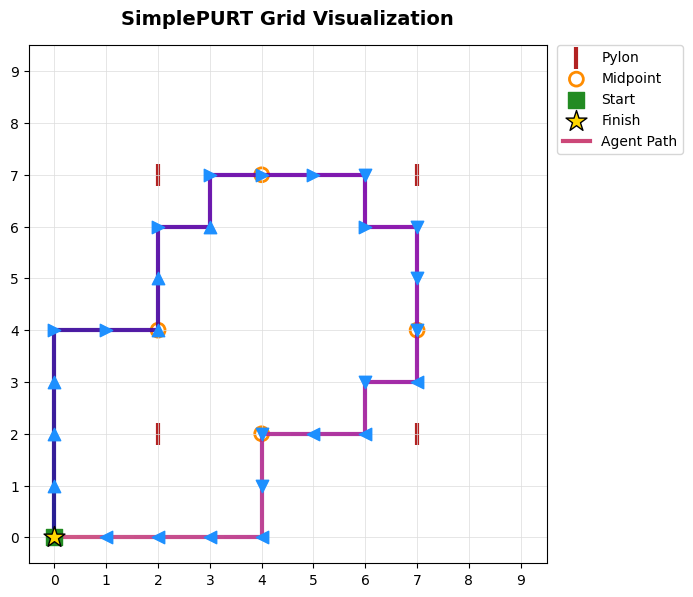

In [77]:
# Policy iteration visualization
PI_env = SimplePURT(GRID_N=10)
PI_policy, PI_V, PI_n_iter = policy_iteration(PI_env, discount_factor=0.9, theta=0.1)
print(f"Policy Iteration completed in {PI_n_iter} iterations.")
test_policy(PI_env, PI_policy)

Value Iteration completed in 16 sweeps.


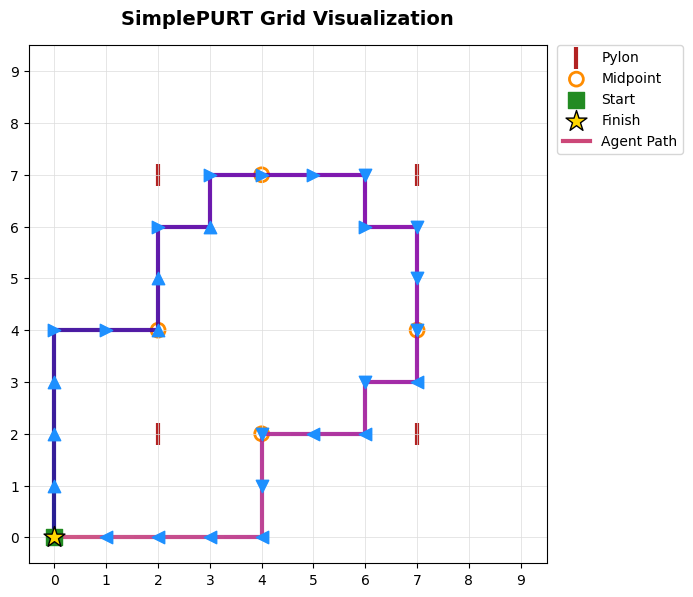

In [78]:
# Value iteration visualization
VI_env = SimplePURT(GRID_N=10)
VI_policy, VI_V, VI_n_iter = value_iteration(VI_env, discount_factor=0.9, theta=0.1)
print(f"Value Iteration completed in {VI_n_iter} sweeps.")
test_policy(VI_env, VI_policy)

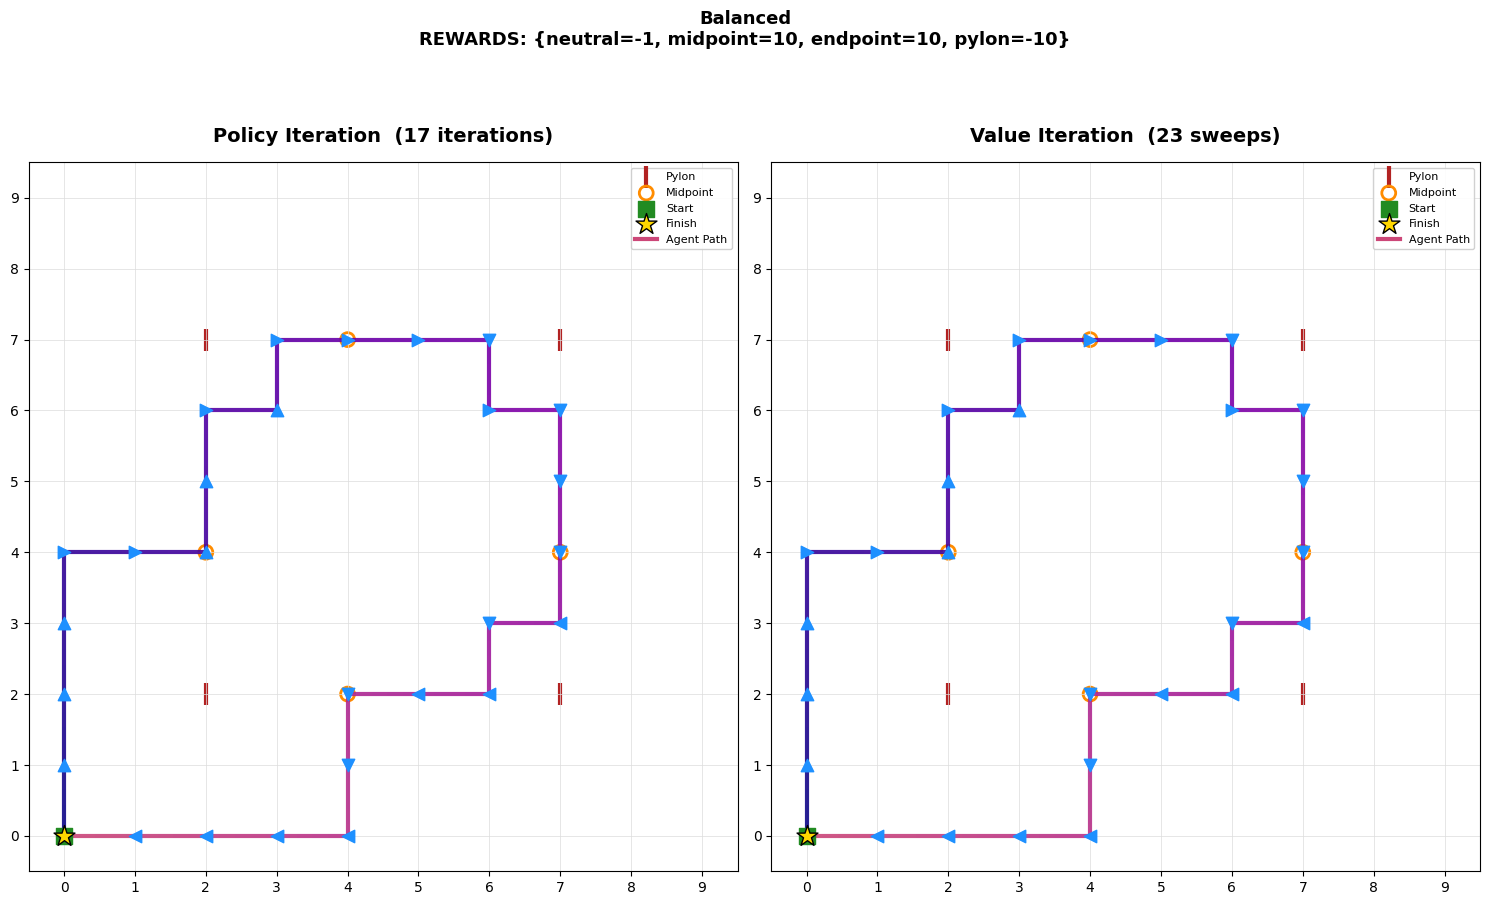

REWARD CONFIG : Balanced
REWARDS       : {'neutral': -1, 'midpoint': 10, 'endpoint': 10, 'pylon': -10}
                              Policy Iteration     Value Iteration
  Outer loop count                          17                  23
  Time (ms)                             302.91              136.13



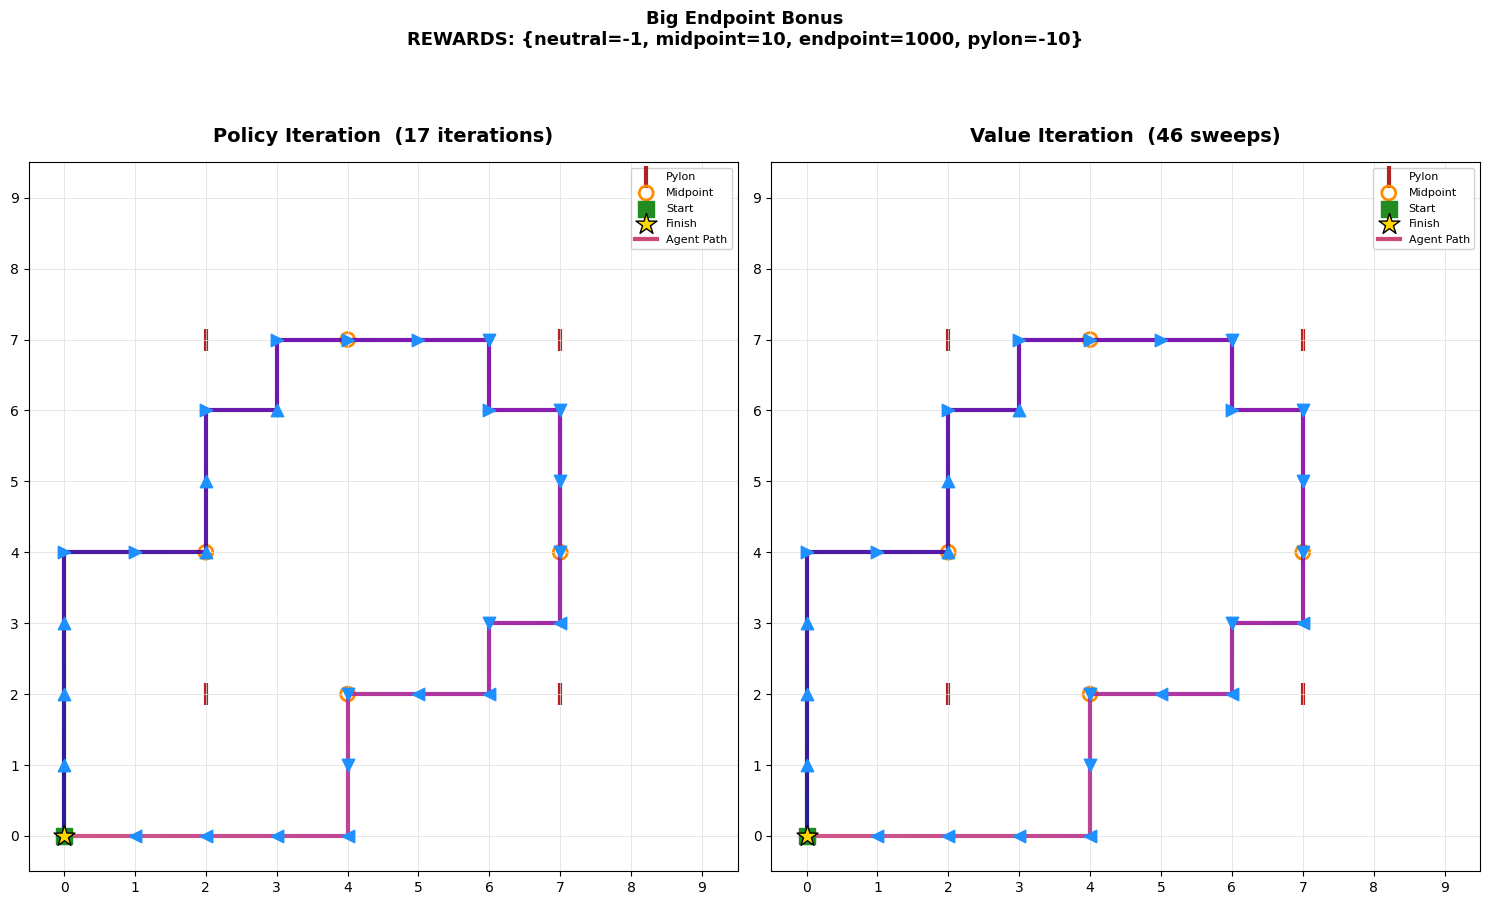

REWARD CONFIG : Big Endpoint Bonus
REWARDS       : {'neutral': -1, 'midpoint': 10, 'endpoint': 1000, 'pylon': -10}
                              Policy Iteration     Value Iteration
  Outer loop count                          17                  46
  Time (ms)                             335.80              258.49



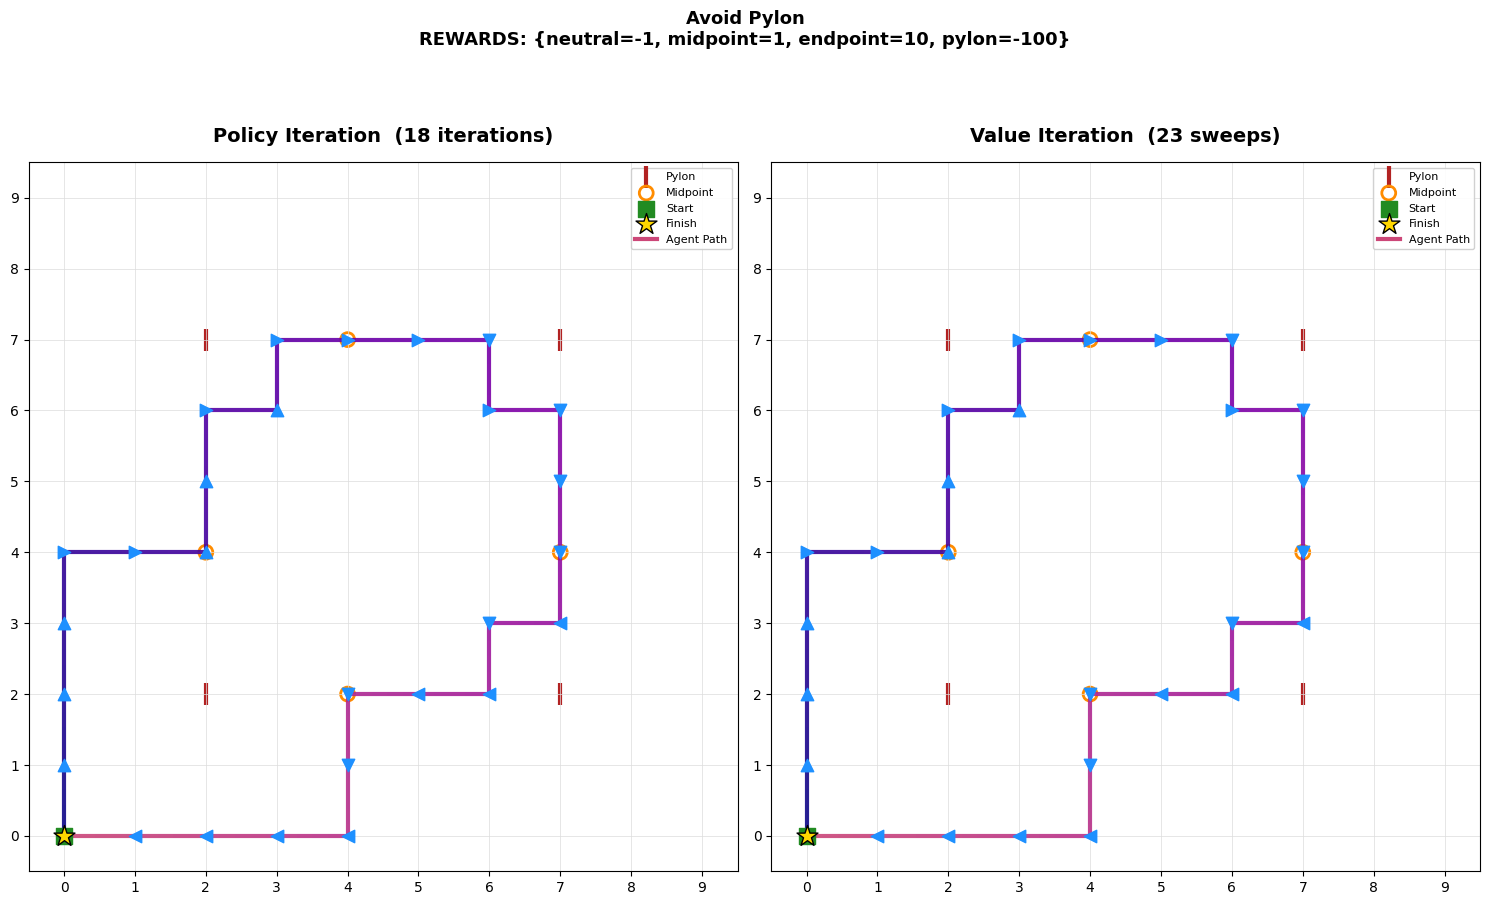

REWARD CONFIG : Avoid Pylon
REWARDS       : {'neutral': -1, 'midpoint': 1, 'endpoint': 10, 'pylon': -100}
                              Policy Iteration     Value Iteration
  Outer loop count                          18                  23
  Time (ms)                             294.15              130.04



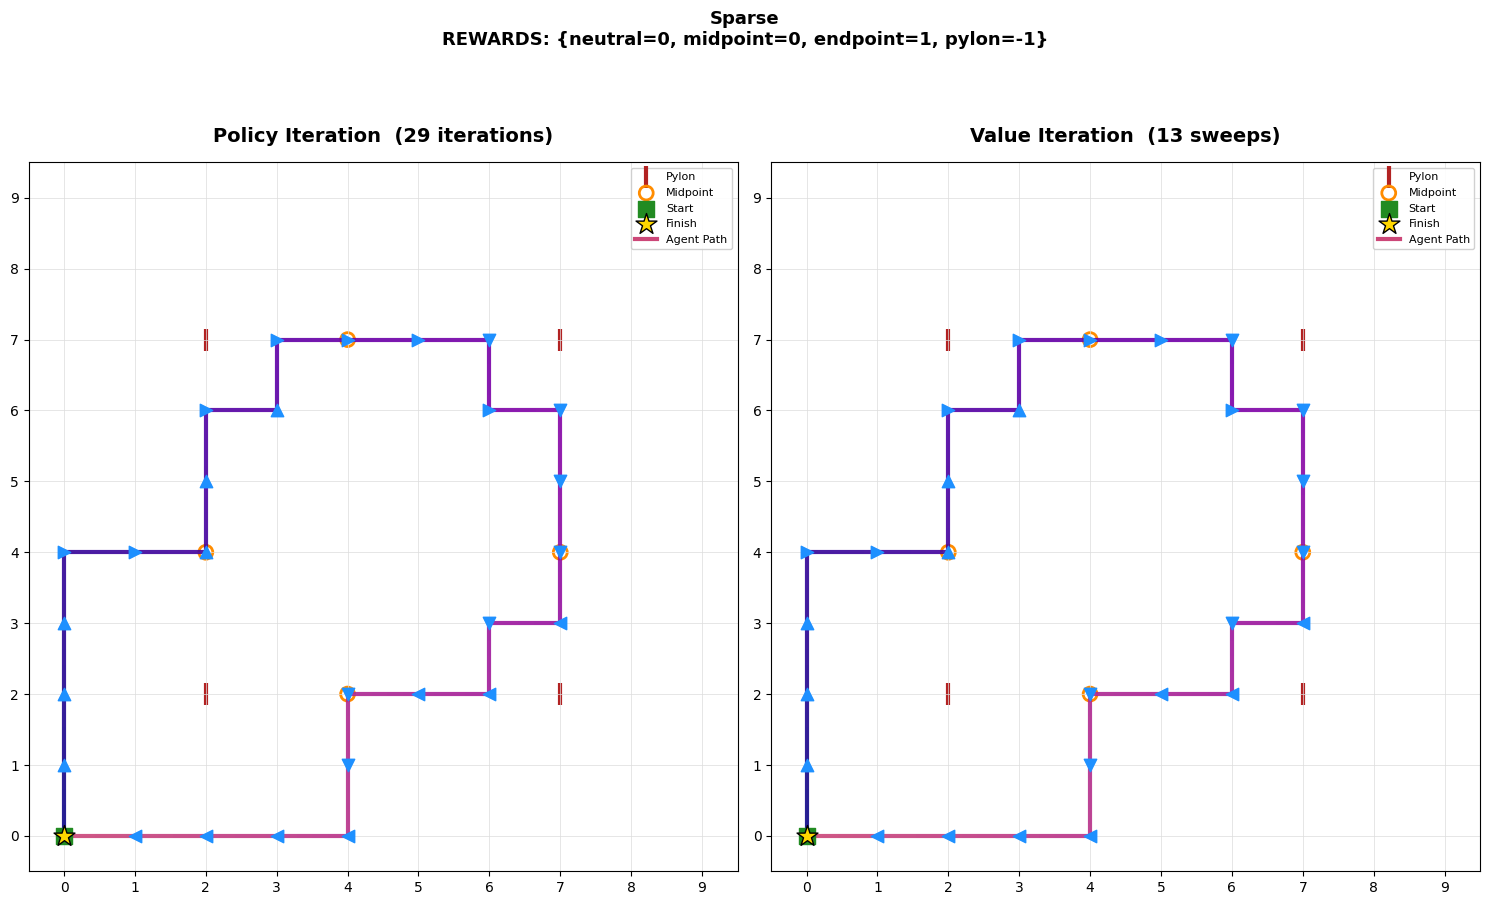

REWARD CONFIG : Sparse
REWARDS       : {'neutral': 0, 'midpoint': 0, 'endpoint': 1, 'pylon': -1}
                              Policy Iteration     Value Iteration
  Outer loop count                          29                  13
  Time (ms)                             382.06               75.51



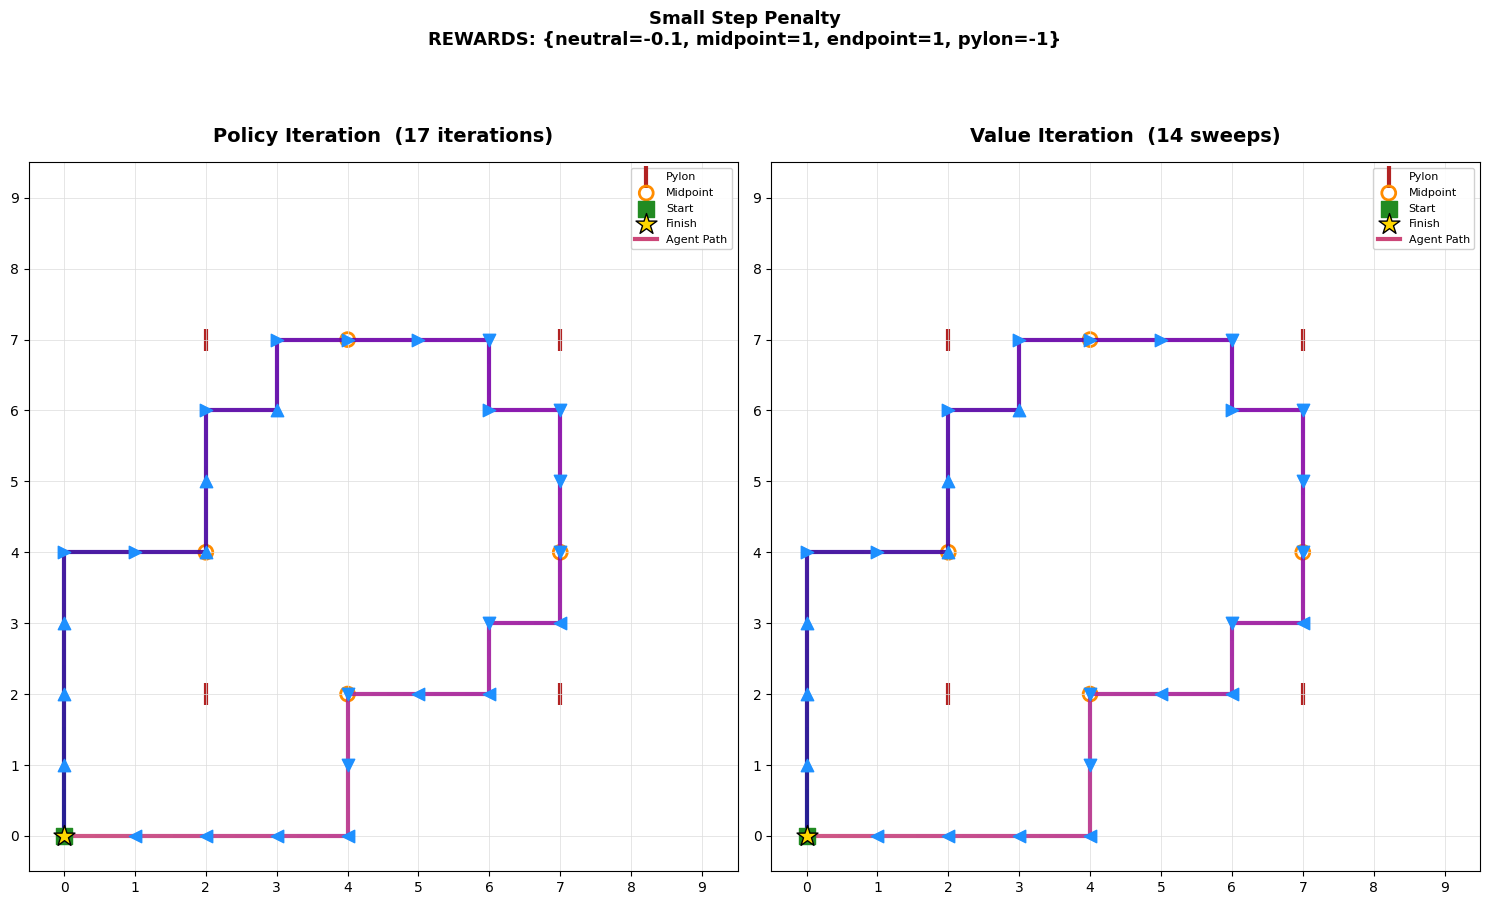

REWARD CONFIG : Small Step Penalty
REWARDS       : {'neutral': -0.1, 'midpoint': 1, 'endpoint': 1, 'pylon': -1}
                              Policy Iteration     Value Iteration
  Outer loop count                          17                  14
  Time (ms)                             256.32               87.15



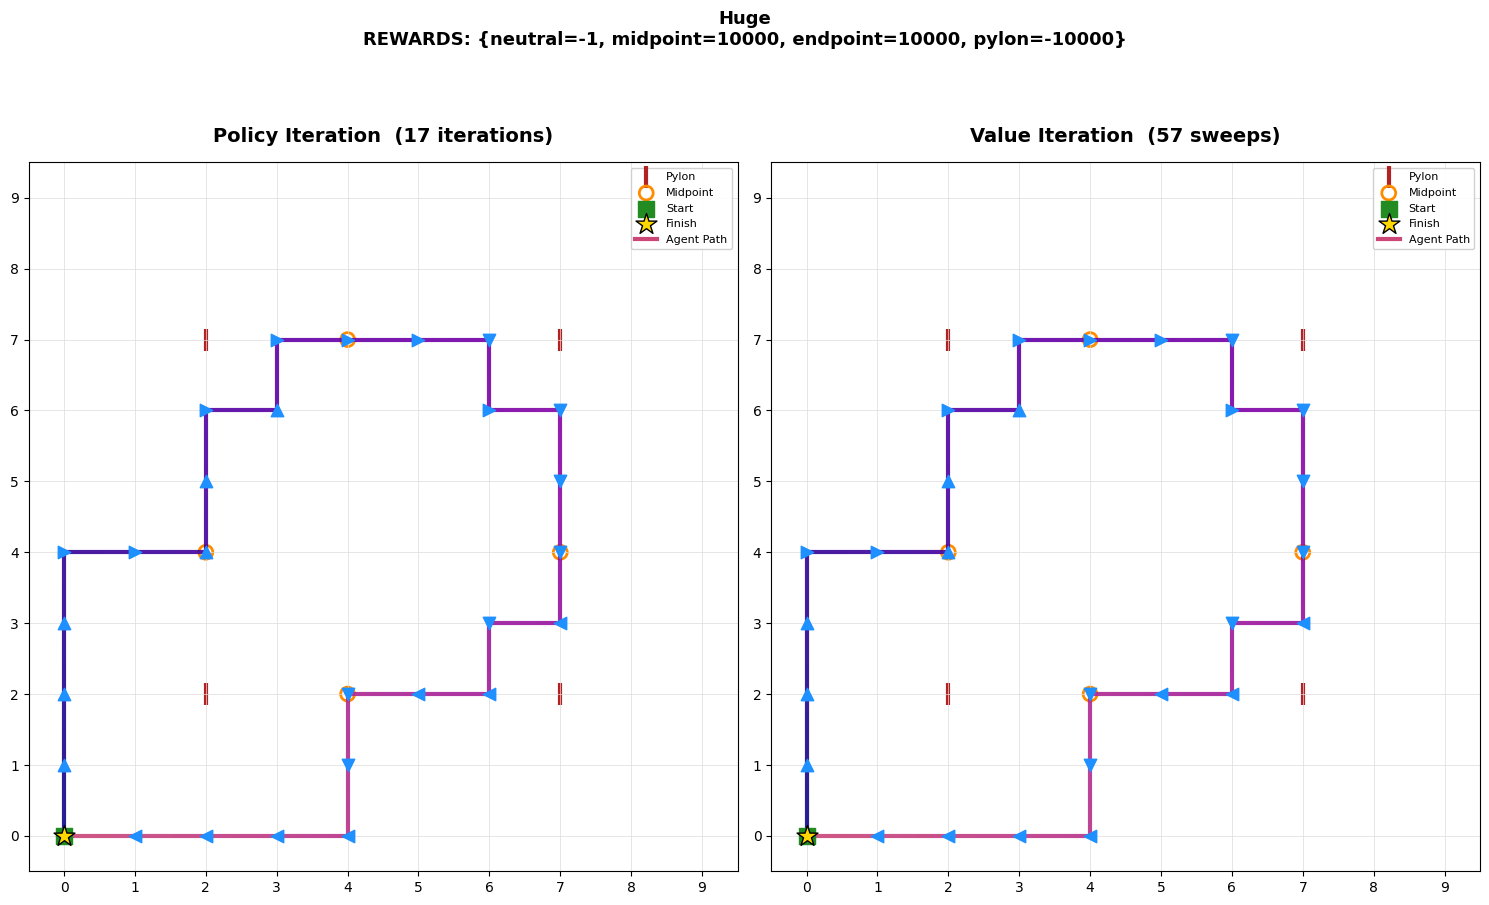

REWARD CONFIG : Huge
REWARDS       : {'neutral': -1, 'midpoint': 10000, 'endpoint': 10000, 'pylon': -10000}
                              Policy Iteration     Value Iteration
  Outer loop count                          17                  57
  Time (ms)                             375.85              334.87



In [84]:
# Reward analysis by outer loop and time

import time

REWARD_CONFIGS = {
    "Balanced":                         {"neutral": -1,   "midpoint": 10, "endpoint": 10,   "pylon": -10},
    "Big Endpoint Bonus":               {"neutral": -1,   "midpoint": 10, "endpoint": 1000, "pylon": -10},
    "Avoid Pylon":                      {"neutral": -1,   "midpoint": 1,  "endpoint": 10,   "pylon": -100},
    "Sparse":                           {"neutral": 0,    "midpoint": 0,  "endpoint": 1,    "pylon": -1},
    "Small Step Penalty":               {"neutral": -0.1, "midpoint": 1,  "endpoint": 1,    "pylon": -1},
    "Huge":                             {"neutral": -1, "midpoint": 10000,  "endpoint": 10000,    "pylon": -10000},

}

def compare_pi_vi(config_name, rewards, grid_n=10, discount_factor=0.9, theta=0.1):
    # Run Policy Iteration
    PI_env = SimplePURT(GRID_N=grid_n, REWARDS=rewards)
    t0 = time.perf_counter()
    PI_policy, PI_V, PI_n_iter = policy_iteration(PI_env, discount_factor=discount_factor, theta=theta)
    PI_time = time.perf_counter() - t0

    # Run Value Iteration
    VI_env = SimplePURT(GRID_N=grid_n, REWARDS=rewards)
    t0 = time.perf_counter()
    VI_policy, VI_V, VI_n_iter = value_iteration(VI_env, discount_factor=discount_factor, theta=theta)
    VI_time = time.perf_counter() - t0

    # Render both resulting policies side-by-side in one figure
    fig, axes = plt.subplots(1, 2, figsize=(15, 10))
    test_policy(PI_env, PI_policy, ax=axes[0], title=f"Policy Iteration  ({PI_n_iter} iterations)", legend_outside=False)
    test_policy(VI_env, VI_policy, ax=axes[1], title=f"Value Iteration  ({VI_n_iter} sweeps)", legend_outside=False)

    reward_str = ", ".join(f"{k}={v}" for k, v in rewards.items())
    fig.suptitle(f"{config_name}\nREWARDS: {{{reward_str}}}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("=" * 78)
    print(f"REWARD CONFIG : {config_name}")
    print(f"REWARDS       : {rewards}")
    print(f"  {'':24}{'Policy Iteration':>20}{'Value Iteration':>20}")
    print(f"  {'Outer loop count':24}{PI_n_iter:>20}{VI_n_iter:>20}")
    print(f"  {'Time (ms)':24}{PI_time*1000:>20.2f}{VI_time*1000:>20.2f}")
    print("=" * 78 + "\n")
    
    return {
        "rewards": rewards,
        "PI_policy": PI_policy, "PI_V": PI_V, "PI_n_iter": PI_n_iter, "PI_time": PI_time,
        "VI_policy": VI_policy, "VI_V": VI_V, "VI_n_iter": VI_n_iter, "VI_time": VI_time,
    }

results = {}
for name, rewards in REWARD_CONFIGS.items():
    results[name] = compare_pi_vi(name, rewards)

In [80]:
# Kaya